<a href="https://colab.research.google.com/github/Rageel-28/244107020136-Machine-Learning/blob/main/JS06/JS06_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS06 - Klasifikasi 2 (Support Vector Machine)
## Lab 5 - Klasifikasi Citra Siang dan Malam

### Pengantar
Pada percobaan ini dilakukan klasifikasi citra dengan dua label: **siang (day)** dan **malam (night)**. Percobaan mencakup pra pengolahan data, ekstraksi fitur, serta klasifikasi dengan *classifier* sederhana (threshold) dan SVM.

**Dataset:** unduh dari halaman modul Lab 5 (file zip berisi folder `images/training/` dan `images/test/`, masing-masing dengan subfolder `day` dan `night`).

*Acknowledgment: Arunn Thevapalan, Day Night Image Classifier (GitHub).*

## Langkah 0 - Import Library

In [ ]:
# Import Required Libraries
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
import pandas as pd

Ekstrak data gambar, lalu definisikan lokasi gambar.

In [ ]:
# Image directories
# Dataset day/night diunduh dari modul (file zip). Letakkan zip di folder yang sama dengan notebook
# (di Google Colab: upload lewat panel Files), lalu sesuaikan nama zip-nya.
import os, zipfile, glob

DATASET_ZIP = "images.zip"

if not os.path.isdir("images"):
    zips = [DATASET_ZIP] if os.path.exists(DATASET_ZIP) else glob.glob("*.zip")
    if zips:
        with zipfile.ZipFile(zips[0]) as z:
            z.extractall(".")
        print("Diekstrak dari", zips[0])
    else:
        print("PERHATIAN: folder 'images' dan file zip tidak ditemukan. Unggah dataset terlebih dahulu.")

train_dir = "images/training/"
test_dir = "images/test/"

Diekstrak dari images.zip


## Langkah 1 - Load Data dan Visualisasikan
Buat fungsi untuk memuat seluruh gambar beserta labelnya. (Label diambil dari nama folder dengan `dir.name` agar tetap berjalan di Windows maupun Linux/Colab.)

In [ ]:
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        label = dir.name
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))

    return img_list

In [ ]:
# Load training data
train_img = load_dataset(train_dir)
print('Jumlah data training:', len(train_img))

Jumlah data training: 240


Cek salah satu data pada list. List harus berisi tuple dua elemen: data gambar dan label gambar.

In [ ]:
# Check the first data
# It should be a tuple consist of arrays of image and image labels
train_img[0]

(array([[[100, 129, 147],
         [101, 130, 148],
         [101, 130, 148],
         ...,
         [ 89, 106, 122],
         [ 86,  99, 116],
         [121, 134, 151]],
 
        [[100, 129, 147],
         [101, 130, 148],
         [101, 130, 148],
         ...,
         [ 89, 106, 122],
         [ 86,  99, 116],
         [121, 134, 151]],
 
        [[100, 129, 147],
         [101, 130, 148],
         [101, 130, 148],
         ...,
         [ 89, 106, 122],
         [ 86,  99, 116],
         [121, 134, 151]],
 
        ...,
 
        [[152, 136, 102],
         [151, 135, 101],
         [151, 135, 101],
         ...,
         [ 59,  63,  40],
         [ 57,  62,  39],
         [ 54,  59,  36]],
 
        [[153, 137, 103],
         [152, 136, 102],
         [151, 135, 101],
         ...,
         [ 59,  63,  40],
         [ 56,  61,  38],
         [ 51,  56,  33]],
 
        [[179, 163, 129],
         [178, 162, 128],
         [177, 161, 127],
         ...,
         [ 64,  68,  45],
  

In [ ]:
# Random size checking
pick_random = np.random.randint(0, len(train_img))

# Check img size
print(f'Image {pick_random}')
print(train_img[pick_random][0].shape)

Image 42
(737, 1024, 3)


Fungsi untuk memvisualkan gambar secara acak.

In [ ]:
# Function to Visualize
def random_img_viz(img_list):
    rand_num = np.random.randint(0, len(img_list))

    img = img_list[rand_num][0]
    label = img_list[rand_num][1]

    plt.imshow(img)
    print(f'Shape\t: {img.shape}')
    print(f'Label\t: {label}')

Shape	: (737, 1024, 3)
Label	: night


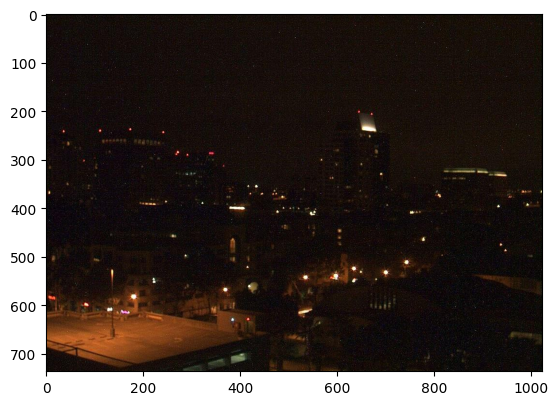

In [ ]:
random_img_viz(train_img)

## Langkah 3 - Pra Pengolahan Data
Dua proses utama: standardisasi ukuran gambar dan *encoding* label.

In [ ]:
def standarized_input(image):
    # resize to w: 1100, h:600
    std_img = cv2.resize(image, (1100,600))

    return std_img

In [ ]:
def label_encoder(label):
    # Encode the label
    # day as 1; night as 0
    num_val = 0

    if(label == 'day'):
        num_val = 1

    return num_val

In [ ]:
def preprocess(img_list):
    std_img_list = []

    for item in img_list:
        image = item[0]
        label = item[1]

        # Standarized the image
        std_img = standarized_input(image)

        # Create the label
        img_label = label_encoder(label)

        std_img_list.append((std_img, img_label))

    return std_img_list

In [ ]:
train_std_img_list = preprocess(train_img)

In [ ]:
# Random size checking
pick_random = np.random.randint(0, len(train_std_img_list))

# Check img size
print(f'Image {pick_random}')
print(train_std_img_list[pick_random][0].shape)

Image 137
(600, 1100, 3)


**WARNING!** Atribut `shape` menampilkan ukuran dalam urutan baris (height) x kolom (width), sehingga hasilnya `(600, 1100, 3)`.

Lakukan inspeksi visual pada gambar hasil pra pengolahan dengan `random_img_viz`.

Shape	: (600, 1100, 3)
Label	: 0


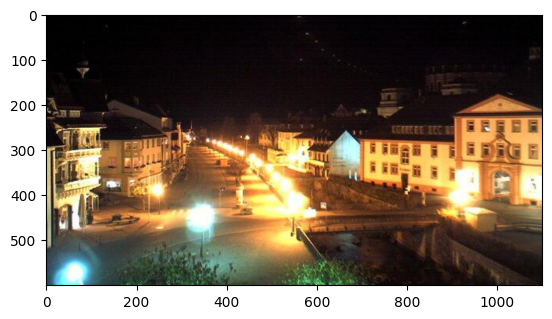

In [ ]:
random_img_viz(train_std_img_list)

## Langkah 4 - Ekstraksi Fitur
Fitur yang digunakan adalah **rata-rata tingkat kecerahan** (*average brightness*). Ruang warna diubah dari RGB ke HSV karena kecerahan dapat diperoleh langsung dari channel *Value*.

In [ ]:
# Get feature based on average brightness using HSV colorspace
def avg_brightness(image):
    # Convert image to HSV
    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Calculate the avg of brightness
    sum_brightness = np.sum(img_hsv[:,:,2]) # take the 3rd value which is the V channel
    area = image.shape[0] * image.shape[1]
    avg = sum_brightness / area

    return avg

Cek pada gambar acak. **INGAT! Gunakan gambar yang telah melalui pra pengolahan data.**

Image 76
Avg Brighness: 104.2330


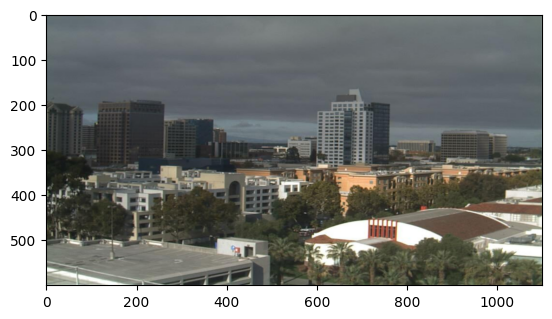

In [ ]:
# Check on random image
rand_img = np.random.randint(0, len(train_std_img_list))

feature_img = train_std_img_list[rand_img][0]

avg_img = avg_brightness(feature_img)

print(f'Image {rand_img}')
print(f'Avg Brighness: {avg_img:.4f}')
plt.imshow(feature_img)

## Langkah 5 - Klasifikasi dengan Metode Threshold
Klasifikasi sederhana menggunakan ambang batas (threshold) pada rata-rata kecerahan yang ditentukan sendiri.

In [ ]:
def predict_label(img, threshold):
    # Computer average brightness
    avg = avg_brightness(img)
    pred = 0

    # Predict the label based on user defined threshold
    if avg > threshold:
        pred = 1

    return pred

Image 109
Actual label: 1
Predicted label: 1


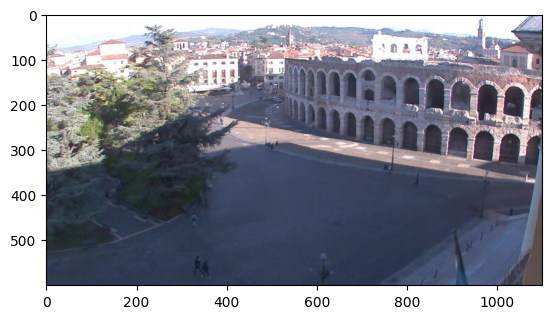

In [ ]:
# Test the classifier on train data
rand_img = np.random.randint(0, len(train_std_img_list))

pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

# Evaluate
print(f'Image {rand_img}')
print(f'Actual label: {train_std_img_list[rand_img][1]}')
print(f'Predicted label: {pred}')
plt.imshow(train_std_img_list[rand_img][0])

## Langkah 6 - Evaluasi Manual
Fungsi evaluasi sederhana: membandingkan label prediksi dengan label sebenarnya pada seluruh data (ingat konsep *confusion matrix*).

In [ ]:
def evaluate(img_list, threshold):
    miss_labels = []

    for file in img_list:
        # Get the ground truth / correct label
        img = file[0]
        label = file[1]

        # Get prediction
        pred_label = predict_label(img, threshold)

        # Compare ground truth and pred
        if pred_label != label:
            miss_labels.append((img, pred_label, label))

    total_img = len(img_list)
    corr_pred = total_img - len(miss_labels)
    accuracy = corr_pred / total_img

    print(f'Accuracy: {accuracy:.4f}')

In [ ]:
# Evaluate on train data
evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8417


Ubah nilai threshold dan amati hasilnya. Selanjutnya evaluasi pada data testing; data testing harus diperlakukan sama dengan data training (pra pengolahan dan ekstraksi fitur).

In [ ]:
# Evaluate on test data

# Load test data
test_img = load_dataset(test_dir)

# Preprocess
test_std_img_list = preprocess(test_img)

# Predict
evaluate(test_std_img_list, threshold=120)

Accuracy: 0.8688


In [ ]:
# Coba beberapa nilai threshold
for th in [80, 100, 120, 140]:
    print(f'Threshold {th}:', end=' ')
    evaluate(train_std_img_list, threshold=th)

Threshold 80: Accuracy: 0.7333
Threshold 100: Accuracy: 0.9042
Threshold 120: Accuracy: 0.8417
Threshold 140: Accuracy: 0.6875


## Klasifikasi dengan SVM
Metode threshold kurang efektif karena nilai ambang harus ditentukan manual. Selanjutnya digunakan model SVM; langkah-langkahnya serupa dan hanya berubah mulai Langkah 4.

## Langkah 4 Alternatif - Membuat Feature Vectors
Seluruh nilai rata-rata kecerahan ditabulasikan ke dalam tabel dengan kolom fitur dan label.

In [ ]:
# Create function to extract feature for every images and stored in tabular data
# Stored in Pandas dataframe
def extract_avg_bright_feature(img_list):
    avg_list = []
    labels = []

    for img in img_list:
        img_avg = avg_brightness(img[0]) # Get the avg brightness from image
        img_label = img[1] # Get the image label

        avg_list.append(img_avg)
        labels.append(img_label)

    # Stack data in columnar way
    data = np.column_stack((avg_list, labels))
    # Create a Pandas dataframe
    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])

    return df

In [ ]:
# Extract feature on train data
train_avg_img = extract_avg_bright_feature(train_std_img_list)
print(f'Shape: {train_avg_img.shape}')
train_avg_img.head()

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,105.600792,1.0
1,117.414992,1.0
2,144.075127,1.0
3,143.364305,1.0
4,170.984826,1.0


In [ ]:
# Do the same thing on test data
test_avg_img = extract_avg_bright_feature(test_std_img_list)
print(f'Shape: {test_avg_img.shape}')
test_avg_img.head()

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,116.048989,1.0
1,194.228062,1.0
2,125.659120,1.0
3,189.320711,1.0
4,110.689276,1.0


## Langkah 5 - Buat Model SVM
Model SVM dengan kernel RBF (default) dibuat menggunakan scikit-learn.

In [ ]:
# import requied library
from sklearn.svm import SVC

# Split data and label
X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
y_train = train_avg_img.iloc[:,1]
X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
y_test = test_avg_img.iloc[:,1]

model = SVC()
model.fit(X_train, y_train)

SVC()

## Langkah 6 - Evaluasi

In [ ]:
from sklearn.metrics import accuracy_score

# Make a prediction on train data
y_train_pred = model.predict(X_train)

# Get the accuracy on train data
acc_train = accuracy_score(y_train, y_train_pred)

# Make a prediction on test data
y_test_pred = model.predict(X_test)

# Get the accuracy on test data
acc_test = accuracy_score(y_test, y_test_pred)

# Print Eval Result
print(f'Accuracy on train: {acc_train}')
print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.8583333333333333
Accuracy on test: 0.9


## Kesimpulan
Pada modul, threshold 120 menghasilkan akurasi 0.8417 (train) dan 0.8688 (test), sedangkan SVM RBF menghasilkan 0.8583 (train) dan 0.9 (test). SVM lebih baik karena batas keputusan dipelajari dari data, bukan ditentukan manual.